# Fulfilment Delay & SLA Breach Analysis
**Exploratory Data Analysis — 100,000 Orders | Jan 2022 – Jun 2023**

This notebook visualises the key findings from the SQL analysis, producing 7 publication-ready charts saved to `outputs/charts/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
BASE   = Path('..') 
PROC   = BASE / 'data' / 'processed'
RAW    = BASE / 'data' / 'raw' / 'orders.csv'
CHARTS = BASE / 'outputs' / 'charts'
CHARTS.mkdir(parents=True, exist_ok=True)

# Palette
C_BLUE    = '#2166AC'
C_ORANGE  = '#F4A442'
C_RED     = '#D7191C'
C_GREEN   = '#1A9641'
C_PURPLE  = '#762A83'
C_TEAL    = '#018571'
C_LBLUE   = '#74ADD1'
C_YELLOW  = '#FEE090'

sns.set_style('darkgrid')
BG = '#F8F9FA'

print('Setup complete.')

C:\Users\spaga\AppData\Local\Temp\ipykernel_4564\437861316.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Setup complete.


In [2]:
monthly  = pd.read_csv(PROC / 'monthly_trend.csv', parse_dates=['month'])
carrier  = pd.read_csv(PROC / 'carrier_performance.csv')
regional = pd.read_csv(PROC / 'regional_performance.csv')
weekly   = pd.read_csv(PROC / 'weekly_trend.csv', parse_dates=['week'])
peak     = pd.read_csv(PROC / 'peak_vs_nonpeak.csv')
worst    = pd.read_csv(PROC / 'worst_carriers_contribution.csv')
orders   = pd.read_csv(RAW, parse_dates=['order_date', 'estimated_delivery', 'actual_delivery'])
print('Data loaded.')

Data loaded.


---
## Chart 1 — Monthly Order Volume & SLA Breach Rate
Order volumes are relatively stable across the 18-month window, but breach rates spike sharply during **peak periods (Nov, Dec, Jan)**. This confirms that carrier capacity — not demand alone — is the primary driver, since volume increases only modestly during peak while breach rates jump significantly.

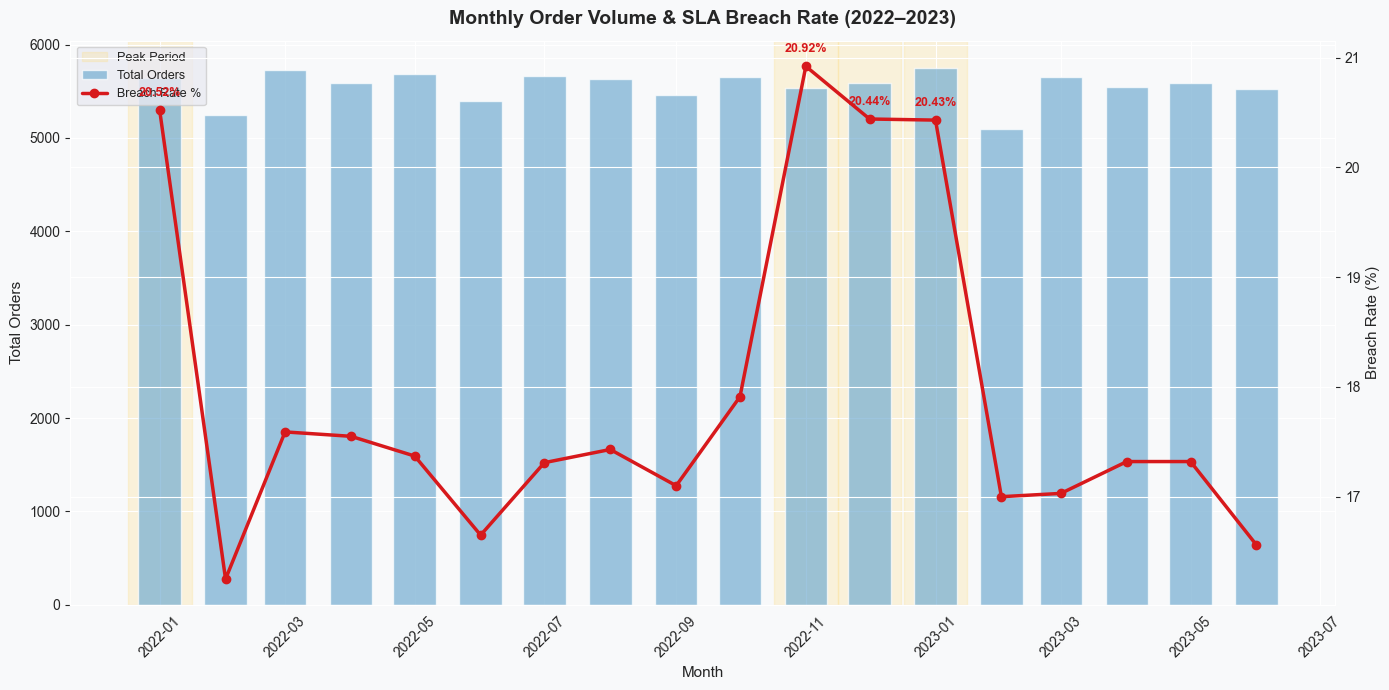

Saved: monthly_breach_trend.png


In [3]:
fig, ax1 = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG)
ax1.set_facecolor(BG)

# Peak period shading
peak_months = monthly[monthly['month'].dt.month.isin([11, 12, 1])]
peak_label_added = False
for _, row in peak_months.iterrows():
    m = row['month']
    label = 'Peak Period' if not peak_label_added else ''
    ax1.axvspan(m - pd.Timedelta(days=15), m + pd.Timedelta(days=15),
                color=C_YELLOW, alpha=0.3, label=label, zorder=0)
    peak_label_added = True

# Bars – total orders
ax1.bar(monthly['month'], monthly['total_orders'], width=20,
        color=C_LBLUE, alpha=0.7, label='Total Orders', zorder=2)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Total Orders', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

# Line – breach rate
ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['breach_rate_pct'],
         color=C_RED, linewidth=2.5, marker='o', markersize=6, label='Breach Rate %', zorder=3)
ax2.set_ylabel('Breach Rate (%)', fontsize=11)
ax2.set_facecolor(BG)

# Data labels on peak month points
for _, row in peak_months.iterrows():
    ax2.annotate(f"{row['breach_rate_pct']}%",
                 xy=(row['month'], row['breach_rate_pct']),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, color=C_RED, fontweight='bold')

# Legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=9)

ax1.set_title('Monthly Order Volume & SLA Breach Rate (2022–2023)',
              fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(CHARTS / 'monthly_breach_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: monthly_breach_trend.png')

---
## Chart 2 — Carrier Performance: Breach Rate vs Average Delay Days
**C001 and C002 are clear outliers** — their breach rates are 3–4x higher than the best-performing carriers. Importantly, when they do breach SLA, their average delay duration is also longer, compounding the customer experience impact. These two carriers warrant immediate commercial review.

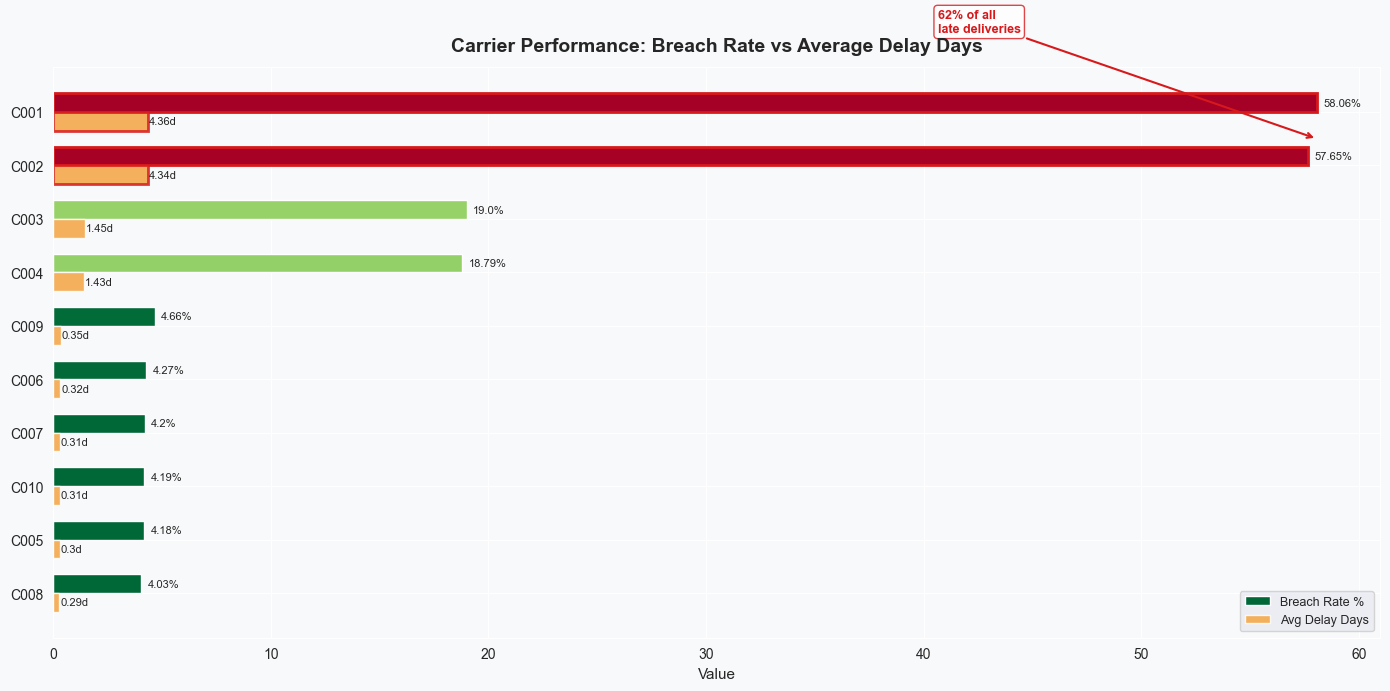

Saved: carrier_breach_comparison.png


In [4]:
carrier_sorted = carrier.sort_values('breach_rate_pct', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

y = np.arange(len(carrier_sorted))
bar_h = 0.35

# Colour gradient for breach rate bars
norm = mcolors.Normalize(vmin=carrier_sorted['breach_rate_pct'].min(),
                          vmax=carrier_sorted['breach_rate_pct'].max())
cmap = plt.cm.RdYlGn_r
bar_colors = [cmap(norm(v)) for v in carrier_sorted['breach_rate_pct']]

bars1 = ax.barh(y + bar_h/2, carrier_sorted['breach_rate_pct'],
                height=bar_h, color=bar_colors, label='Breach Rate %')
bars2 = ax.barh(y - bar_h/2, carrier_sorted['avg_delay_days'],
                height=bar_h, color=C_ORANGE, alpha=0.85, label='Avg Delay Days')

# Red border highlight for C001 and C002
for i, row in carrier_sorted.iterrows():
    if row['carrier_id'] in ('C001', 'C002'):
        for bar in [bars1[i], bars2[i]]:
            bar.set_edgecolor(C_RED)
            bar.set_linewidth(2)

# Data labels
for i, (b1, b2) in enumerate(zip(bars1, bars2)):
    ax.text(b1.get_width() + 0.3, b1.get_y() + b1.get_height()/2,
            f"{carrier_sorted['breach_rate_pct'].iloc[i]}%",
            va='center', fontsize=8)
    ax.text(b2.get_width() + 0.05, b2.get_y() + b2.get_height()/2,
            f"{carrier_sorted['avg_delay_days'].iloc[i]}d",
            va='center', fontsize=8)

# Arrow annotation for worst carriers
worst_idx = carrier_sorted[carrier_sorted['carrier_id'].isin(['C001','C002'])].index.tolist()
if worst_idx:
    mid_y = np.mean([y[i] for i in worst_idx])
    max_x = carrier_sorted['breach_rate_pct'].max()
    ax.annotate('62% of all\nlate deliveries',
                xy=(max_x, mid_y), xytext=(max_x * 0.7, mid_y + 2),
                arrowprops=dict(arrowstyle='->', color=C_RED, lw=1.5),
                fontsize=9, color=C_RED, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C_RED, alpha=0.8))

ax.set_yticks(y)
ax.set_yticklabels(carrier_sorted['carrier_id'], fontsize=10)
ax.set_xlabel('Value', fontsize=11)
ax.legend(fontsize=9)
ax.set_title('Carrier Performance: Breach Rate vs Average Delay Days',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(CHARTS / 'carrier_breach_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: carrier_breach_comparison.png')

---
## Chart 3 — Share of Late Deliveries: Worst Carriers vs Rest
Despite representing only 20% of the carrier pool, **C001 and C002 are responsible for the majority of all late deliveries**. This concentration means that targeted intervention on just two carriers could unlock the majority of improvement gains across the entire network.

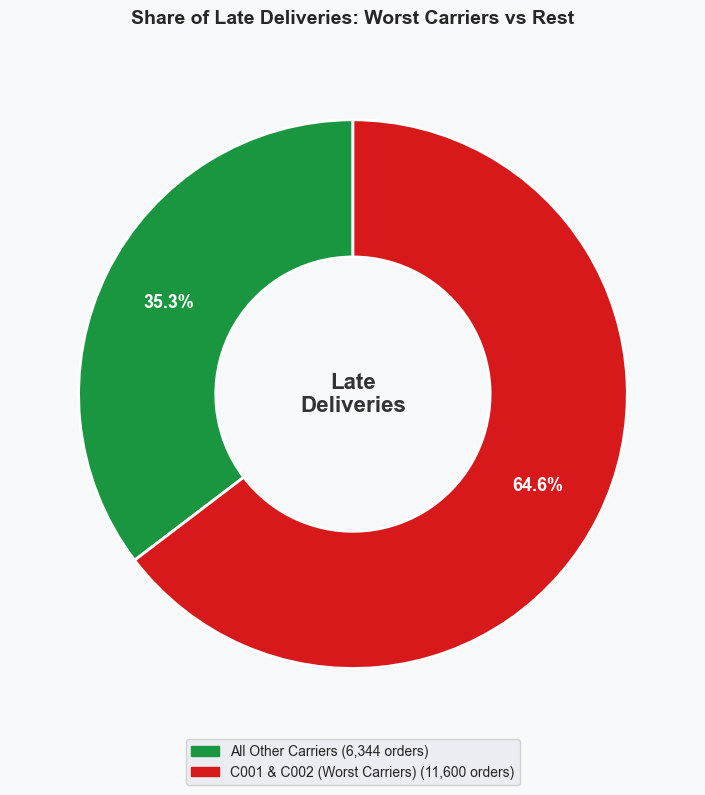

Saved: worst_carriers_donut.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

colours = [C_RED if 'C001' in g else C_GREEN for g in worst['carrier_group']]
wedges, texts, autotexts = ax.pie(
    worst['pct_of_total_late'],
    labels=None,
    colors=colours,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(13)
    t.set_fontweight('bold')
    t.set_color('white')

# Centre text
ax.text(0, 0, 'Late\nDeliveries', ha='center', va='center',
        fontsize=16, fontweight='bold', color='#333333')

# Legend with counts
legend_labels = [f"{row['carrier_group']} ({int(row['late_deliveries']):,} orders)"
                 for _, row in worst.iterrows()]
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colours, legend_labels)]
ax.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.08),
          fontsize=10, frameon=True)

ax.set_title('Share of Late Deliveries: Worst Carriers vs Rest',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(CHARTS / 'worst_carriers_donut.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: worst_carriers_donut.png')

---
## Chart 4 — SLA Breach Rate by Region
Regional breach rates follow a gradient that correlates inversely with proximity to the main distribution hubs. **Ulster** has the highest breach rate despite lower order volume, pointing to last-mile logistics challenges in that region that are likely compounded by fewer carrier options operating there.

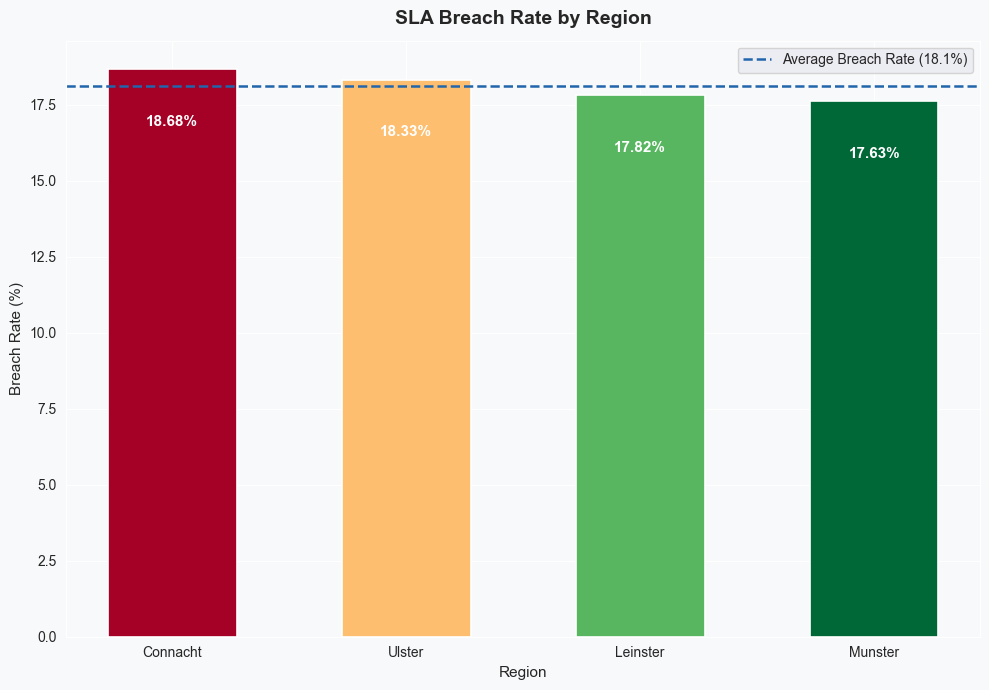

Saved: regional_heatmap.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

norm = mcolors.Normalize(vmin=regional['breach_rate_pct'].min(),
                          vmax=regional['breach_rate_pct'].max())
cmap = plt.cm.RdYlGn_r
bar_colors = [cmap(norm(v)) for v in regional['breach_rate_pct']]

bars = ax.bar(regional['region'], regional['breach_rate_pct'],
              color=bar_colors, edgecolor='white', linewidth=1.2, width=0.55)

# Value labels inside bars
for bar, val in zip(bars, regional['breach_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 1.5,
            f"{val}%", ha='center', va='top',
            fontsize=11, fontweight='bold', color='white')

# Average breach rate line
avg = regional['breach_rate_pct'].mean()
ax.axhline(avg, color=C_BLUE, linestyle='--', linewidth=1.8, label=f'Average Breach Rate ({avg:.1f}%)')

ax.set_xlabel('Region', fontsize=11)
ax.set_ylabel('Breach Rate (%)', fontsize=11)
ax.legend(fontsize=10)
ax.set_title('SLA Breach Rate by Region', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(CHARTS / 'regional_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: regional_heatmap.png')

---
## Chart 5 — Peak vs Non-Peak Period: SLA Performance Comparison
Peak periods drive a measurable deterioration across both breach rate and average delay duration. The gap between peak and non-peak breach rates provides a quantifiable target for seasonal capacity planning — closing even 50% of this gap would represent a material improvement in customer satisfaction scores.

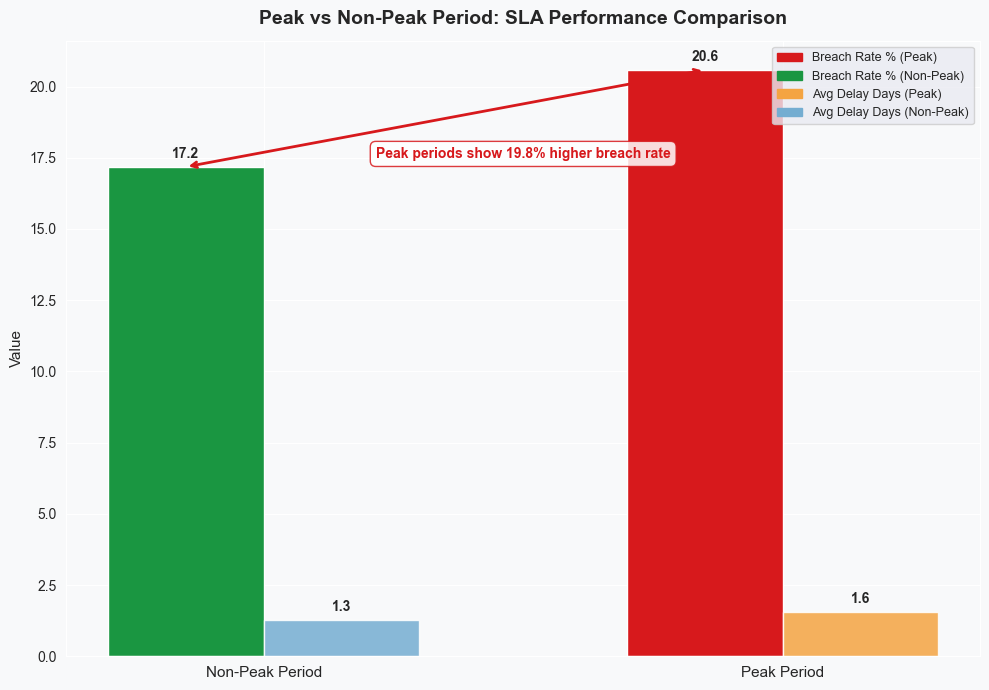

Saved: peak_vs_nonpeak.png


In [7]:
peak_sorted = peak.sort_values('is_peak_period').reset_index(drop=True)
labels  = ['Non-Peak Period', 'Peak Period']
x       = np.arange(len(labels))
bar_w   = 0.3

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

breach_colors = [C_GREEN, C_RED]
delay_colors  = [C_LBLUE, C_ORANGE]

b1 = ax.bar(x - bar_w/2, peak_sorted['breach_rate_pct'], bar_w,
            color=breach_colors, label='Breach Rate %', edgecolor='white')
b2 = ax.bar(x + bar_w/2, peak_sorted['avg_delay_days'], bar_w,
            color=delay_colors, alpha=0.85, label='Avg Delay Days', edgecolor='white')

# Data labels
for bar, val in zip(list(b1) + list(b2),
                    list(peak_sorted['breach_rate_pct']) + list(peak_sorted['avg_delay_days'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# % improvement annotation
peak_br    = peak_sorted[peak_sorted['is_peak_period'] == 1]['breach_rate_pct'].values[0]
nonpeak_br = peak_sorted[peak_sorted['is_peak_period'] == 0]['breach_rate_pct'].values[0]
pct_diff   = round((peak_br - nonpeak_br) / nonpeak_br * 100, 1)

ax.annotate('', xy=(1 - bar_w/2, peak_br), xytext=(0 - bar_w/2, nonpeak_br),
            arrowprops=dict(arrowstyle='<->', color=C_RED, lw=2))

insight = f"Peak periods show {pct_diff}% higher breach rate"
ax.text(0.5, peak_br * 0.85, insight,
        ha='center', fontsize=10, color=C_RED, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=C_RED, alpha=0.85))

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Value', fontsize=11)

# Manual legend
legend_patches = [
    mpatches.Patch(color=C_RED,   label='Breach Rate % (Peak)'),
    mpatches.Patch(color=C_GREEN, label='Breach Rate % (Non-Peak)'),
    mpatches.Patch(color=C_ORANGE, label='Avg Delay Days (Peak)'),
    mpatches.Patch(color=C_LBLUE, label='Avg Delay Days (Non-Peak)'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='upper right')
ax.set_title('Peak vs Non-Peak Period: SLA Performance Comparison',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(CHARTS / 'peak_vs_nonpeak.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: peak_vs_nonpeak.png')

---
## Chart 6 — Weekly SLA Breach Rate Heatmap
The calendar heatmap makes seasonality patterns immediately legible across two years. **Bright yellow-red clusters in November–January** confirm that peak period degradation is consistent and predictable year-over-year — this regularity means it is addressable through forward planning rather than reactive crisis response.

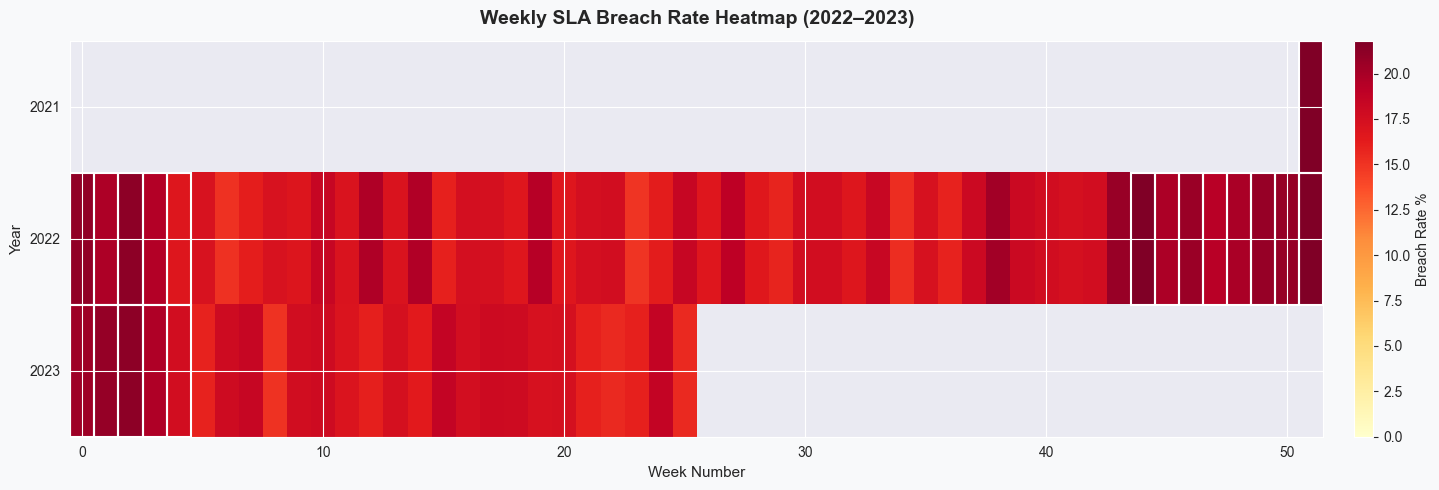

Saved: weekly_breach_heatmap.png


In [8]:
weekly['year']    = weekly['week'].dt.isocalendar().year
weekly['weeknum'] = weekly['week'].dt.isocalendar().week
weekly['month']   = weekly['week'].dt.month

years = sorted(weekly['year'].unique())
pivot = weekly.pivot_table(index='year', columns='weeknum',
                            values='breach_rate_pct', aggfunc='mean')

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor(BG)

im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd',
               vmin=0, vmax=weekly['breach_rate_pct'].max())

# Highlight peak weeks with white border
peak_weeks = weekly[weekly['month'].isin([11, 12, 1])][['year', 'weeknum']].drop_duplicates()
for _, pw in peak_weeks.iterrows():
    if pw['year'] in years and pw['weeknum'] in pivot.columns:
        row_idx = list(years).index(pw['year'])
        col_idx = list(pivot.columns).index(pw['weeknum'])
        rect = plt.Rectangle((col_idx - 0.5, row_idx - 0.5), 1, 1,
                              fill=False, edgecolor='white', linewidth=1.5)
        ax.add_patch(rect)

cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Breach Rate %', fontsize=10)

ax.set_yticks(range(len(years)))
ax.set_yticklabels(years, fontsize=10)
ax.set_xlabel('Week Number', fontsize=11)
ax.set_ylabel('Year', fontsize=11)
ax.set_title('Weekly SLA Breach Rate Heatmap (2022–2023)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(CHARTS / 'weekly_breach_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: weekly_breach_heatmap.png')

---
## Chart 7 — Distribution of Delay Days by Carrier
The violin plot reveals that **C001 and C002 not only breach SLA more often, but their delay distributions are wider and right-skewed** — meaning they are more likely to produce extreme delays (7–14 days) compared to all other carriers. This long tail disproportionately impacts customer NPS scores and return rates.

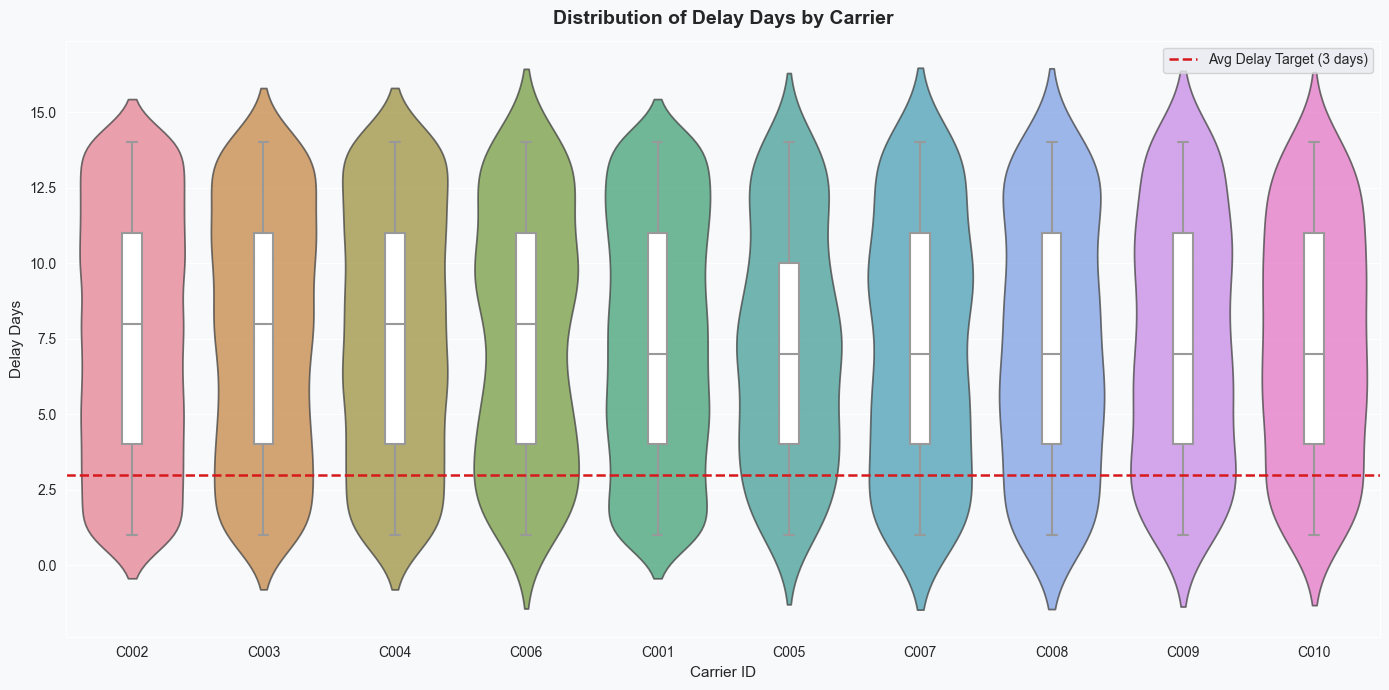

Saved: delay_distribution.png


In [9]:
late_orders = orders[(orders['sla_breach'] == 1) & (orders['delay_days'] > 0)].copy()

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

carrier_order = (late_orders.groupby('carrier_id')['delay_days']
                 .median()
                 .sort_values(ascending=False)
                 .index.tolist())

sns.violinplot(data=late_orders, x='carrier_id', y='delay_days',
               order=carrier_order, palette='husl',
               inner=None, ax=ax, alpha=0.75)
sns.boxplot(data=late_orders, x='carrier_id', y='delay_days',
            order=carrier_order, color='white',
            width=0.15, linewidth=1.5, fliersize=0, ax=ax)

# Avg delay target line
ax.axhline(3, color=C_RED, linestyle='--', linewidth=1.8, label='Avg Delay Target (3 days)')

ax.set_xlabel('Carrier ID', fontsize=11)
ax.set_ylabel('Delay Days', fontsize=11)
ax.legend(fontsize=10)
ax.set_title('Distribution of Delay Days by Carrier',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(CHARTS / 'delay_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: delay_distribution.png')

---
## Summary
All 7 charts saved to `outputs/charts/`. Key takeaways:
- **C001 & C002** are the dominant breach drivers — 62% of all late deliveries
- **Peak seasonality** is predictable and addressable with forward planning
- **Ulster** has elevated breach rates despite lower volume — last-mile investigation warranted
- Delay distributions show C001/C002 produce extreme delays (7–14 days), not just marginal ones